In [1]:
#Carregando bibliotecas e datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

users = pd.read_csv(
    "../data/processed/users_clean.csv"
)

user_plan = pd.read_csv(
    "../data/processed/user_plan_clean.csv",
    parse_dates=["data_inicio"]
)

user_app = pd.read_csv(
    "../data/processed/user_app_clean.csv",
    parse_dates=["checkin"]
)

activities = pd.read_csv(
    "../data/processed/activities_clean.csv",
    parse_dates=["date"]
)

weekly_visits = pd.read_csv(
    "../data/processed/weekly_visits_clean.csv"
)

challenges = pd.read_csv(
    "../data/processed/challenges_clean.csv",
    parse_dates=["data_inicio", "data_fim"]
)

desafio_usuario = pd.read_csv(
    "../data/processed/desafio_usuario_clean.csv",
    parse_dates=["data_desafio"]
)

In [2]:
#Criando dicionário dos datasets
datasets = {
    'users': users,
    'user_plan': user_plan,
    'user_app': user_app,
    'activities': activities,
    'weekly_visits': weekly_visits,
    'challenges': challenges,
    'desafio_usuario': desafio_usuario
}

Hipótese 1: *Desafios aumentam engajamento:*

    1. Usuários que participam de desafios (variando de acordo com o desafio) apresentam maior nível de atividade física do que usuários que não participam, a depender do tempo semanal de realização da atividade.

        Métricas associadas:
            Média de steps por usuário;
            Média de calories_burned;
            Atividades que apresentam médias maiores de steps e calorias queimadas;
            Semanas que apresentam mais densidade de participações e calorias;
            Número de atividades registradas.

In [3]:
#Hipótese 1:

##Será usado como unidade de análise o usuário em si, e não a linha de atividade

###Agregando comportamento por usuário
df_user = activities.groupby('user_id').agg({
   'steps':'mean',
   'calories_burned':'mean',
   'activity_id':'count' 
}).reset_index()

###Renomeando as colunas
df_user.rename(columns={
    'steps':'steps_mean',
    'calories_burned':'calories_mean',
    'activity_id':'n_activities'
}, inplace=True)

In [4]:
#Adicionando a variável de participação
participants = desafio_usuario['user_id'].unique()

users['participa'] = users['user_id'].isin(participants)

#Dando Merge
df_user = df_user.merge(
    users[['user_id', 'participa', 'age_group', 'gender', 'distance_to_gym']],
    on='user_id'
)

#Merge de atividades
df_activities_full = activities.merge(
    users[['user_id', 'participa', 'age_group', 'gender']],
    on='user_id',
    how='left'
)

In [5]:
#Contagem do grupo de participantes
df_user['participa'].value_counts()

participa
False    600
True     400
Name: count, dtype: int64

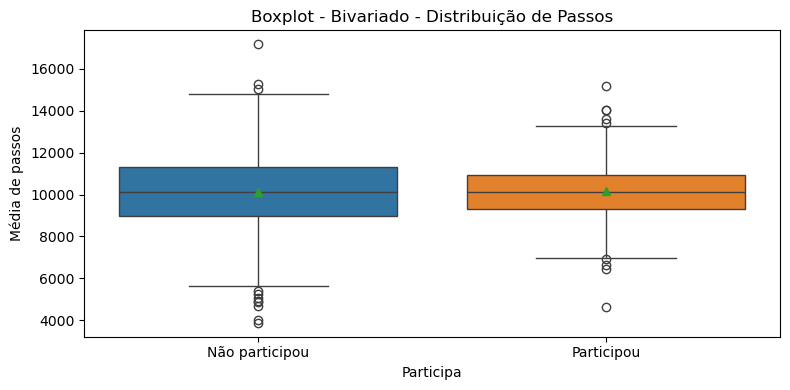

In [6]:
#Entendendo a distribuição dos valores de passos
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

df_user['participa_label'] = df_user['participa'].map({True: 'Participou', False: 'Não participou'})

plt.figure(figsize=(8,4))

sns.boxplot(data=df_user,
    x='participa',
    y='steps_mean',
    showmeans=True,
    hue='participa_label',
    palette='tab10',
    legend=False
)

plt.xlabel('Participa')
plt.ylabel('Média de passos')
plt.xticks([0,1], ['Não participou', 'Participou'])

plt.title('Boxplot - Bivariado - Distribuição de Passos')

file_path = '../outputs/EDA_Bivariate/boxplot_bivariado_passos.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

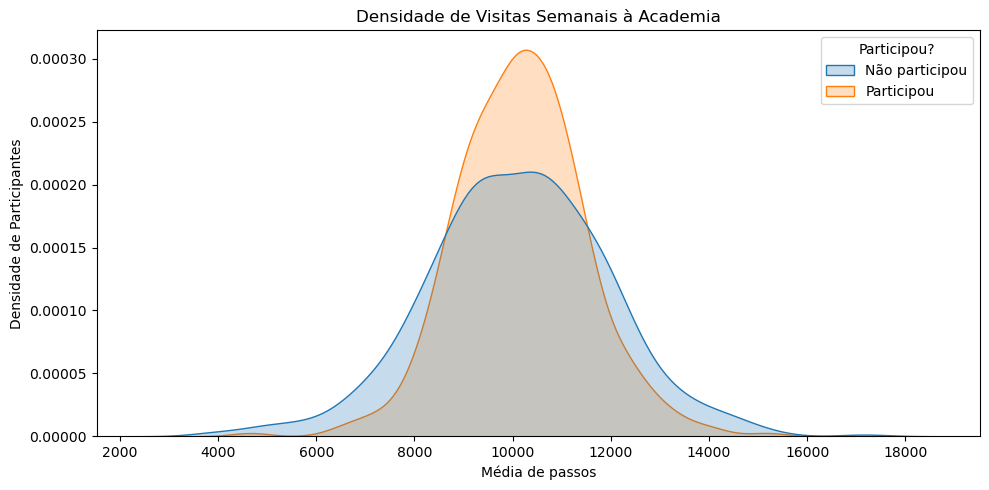

In [7]:
#KDE para densidade de passos e participantes
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(10,5))

sns.kdeplot(data=df_user,
        x='steps_mean',
        hue='participa_label',
        fill=True,
        common_norm=False
)
sns.move_legend(plt.gca(), 'upper right', title='Participou?')

plt.title('Densidade de Visitas Semanais à Academia')
plt.xlabel('Média de passos')
plt.ylabel('Densidade de Participantes')

file_path = "../outputs/EDA_Bivariate/kdeplot_Densidade_de_Passos_Semanais_a_Academia.png"

plt.tight_layout()
plt.savefig(file_path ,bbox_inches='tight')
plt.show()
plt.close()

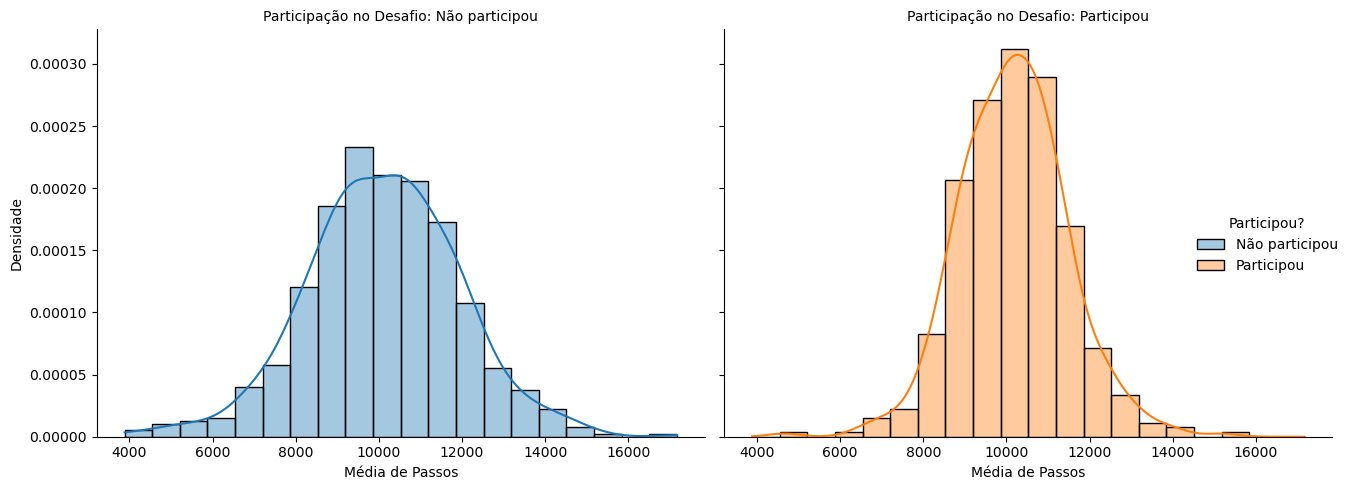

In [8]:
#Verificando o efeito da participação nos passos dados
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

g_passos = sns.displot(
    data=df_user,
    x='steps_mean',
    hue='participa_label',
    col='participa_label',    #Separando em dois gráficos
    kind='hist',              #Definindo o histograma
    kde=True,
    stat='density',           #Transformando 'Contagem' em 'Proporção'
    common_norm=False,        #Tratando cada grupo como 100%
    bins=20,
    palette='tab10',
    alpha=0.4,                #Transparência para ver onde as linhas se cruzam
    height=5,                 #Altura dos gráficos
    aspect=1.2                #Largura dos gráficos
)

g_passos._legend.set_title('Participou?')

g_passos.set_axis_labels('Média de Passos', 'Densidade')
g_passos.set_titles('Participação no Desafio: {col_name}')

file_path = "../outputs/EDA_Bivariate/distplot_passos_participa_facet.png"

plt.tight_layout()
plt.savefig(file_path ,bbox_inches='tight')
plt.show()
plt.close()

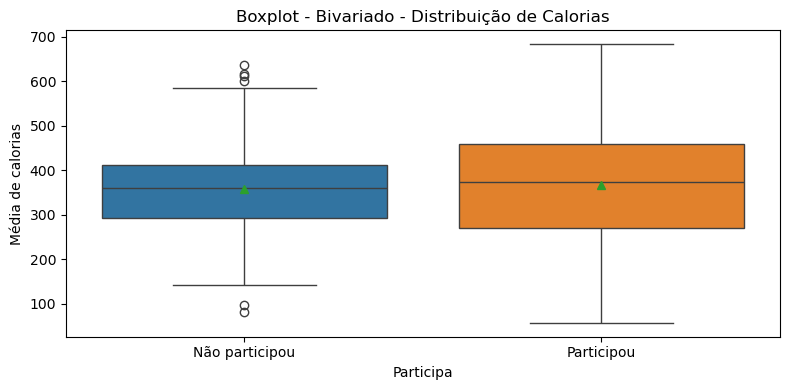

In [9]:
#Entendendo a distribuição dos valores de calorias
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(8,4))

sns.boxplot(data=df_user,
    x='participa',
    y='calories_mean',
    showmeans=True,
    hue='participa_label',
    palette='tab10',
    legend=False
)

plt.xlabel('Participa')
plt.ylabel('Média de calorias')
plt.xticks([0,1], ['Não participou', 'Participou'])

plt.title('Boxplot - Bivariado - Distribuição de Calorias')

file_path = '../outputs/EDA_Bivariate/boxplot_bivariado_calorias.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

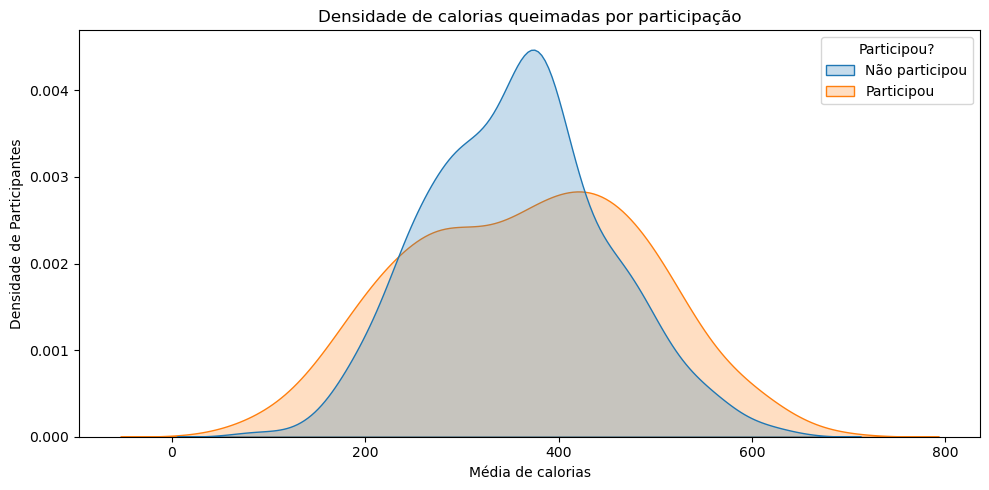

In [10]:
#Analisando a densidade de calorias queimadas de quem participou ou não
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(10,5))

sns.kdeplot(data=df_user,
            x='calories_mean',
            hue='participa_label',
            fill=True,
            common_norm=False)
sns.move_legend(plt.gca(), 'upper right', title='Participou?')

plt.title('Densidade de calorias queimadas por participação')
plt.xlabel('Média de calorias')
plt.ylabel('Densidade de Participantes')

file_path = "../outputs/EDA_Bivariate/kde_calorias_participa.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

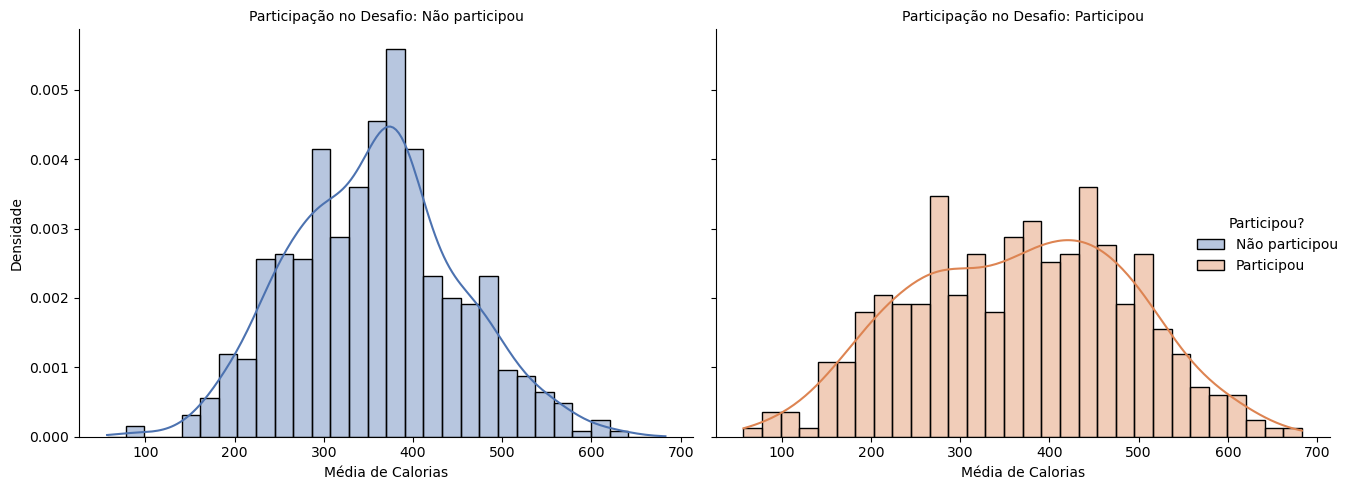

In [11]:
#Analisando a distribuição de calorias queimadas de quem participou ou não
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

g_calories = sns.displot(
    data=df_user,
    x='calories_mean',
    hue='participa_label',
    col='participa_label',
    kind='hist',
    kde=True,
    stat='density',     #Transformando 'Contagem' em 'Proporção'
    common_norm=False,  #Tratando cada grupo como 100%
    bins=30,
    palette='deep',
    alpha=0.4,          #Transparência para ver onde as linhas se cruzam
    height=5,           #Altura dos gráficos
    aspect=1.2          #Largura dos gráficos
)
g_calories._legend.set_title('Participou?')

g_calories.set_axis_labels('Média de Calorias', 'Densidade')
g_calories.set_titles('Participação no Desafio: {col_name}')

file_path = "../outputs/EDA_Bivariate/distplot_passos_participa_facet.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

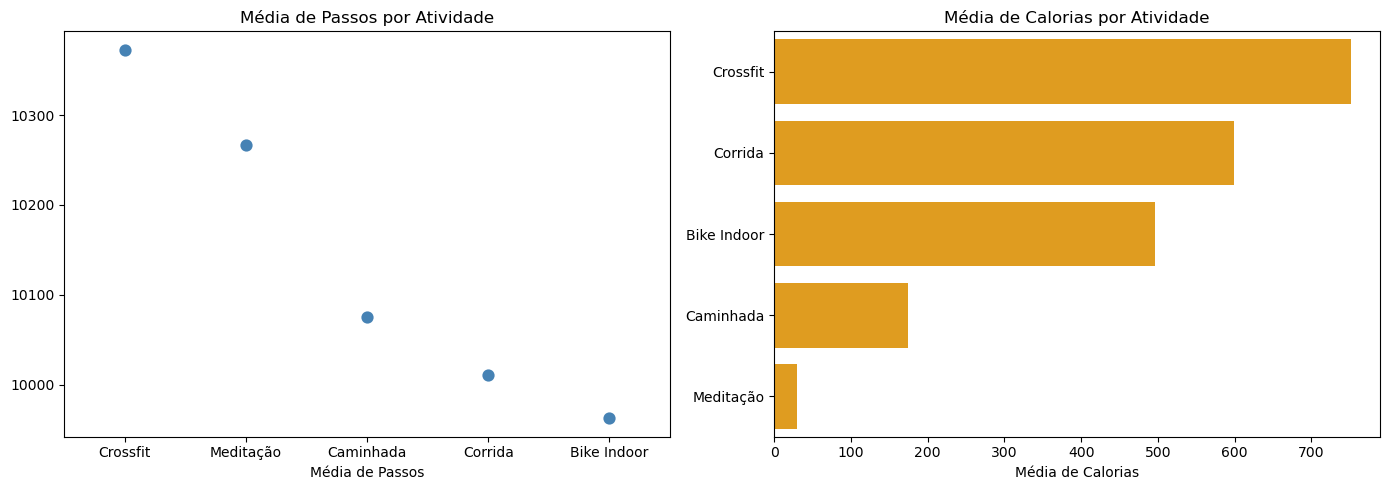

In [12]:
#Agregando atividades com maiores médias de passos e calorias
act_stats = df_activities_full.groupby('activity_type').agg(
    steps_mean=('steps', 'mean'),
    calories_mean=('calories_burned', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico de média de passos por atividade
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.pointplot(
    data=act_stats.sort_values('steps_mean', ascending=False),
    x='activity_type',
    y='steps_mean',
    ax=axes[0],
    color='steelblue',
    linestyles='none'
)

axes[0].set_title('Média de Passos por Atividade')
axes[0].set_xlabel('Média de Passos')
axes[0].set_ylabel('')

#Média de calorias por atividade
sns.barplot(
    data=act_stats.sort_values('calories_mean', ascending=False),
    y='activity_type',
    x='calories_mean',
    ax=axes[1],
    color='orange',
)

axes[1].set_title('Média de Calorias por Atividade')
axes[1].set_xlabel('Média de Calorias')
axes[1].set_ylabel('')

file_path = "../outputs/EDA_Bivariate/barplot_atividade_steps_calorias.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()



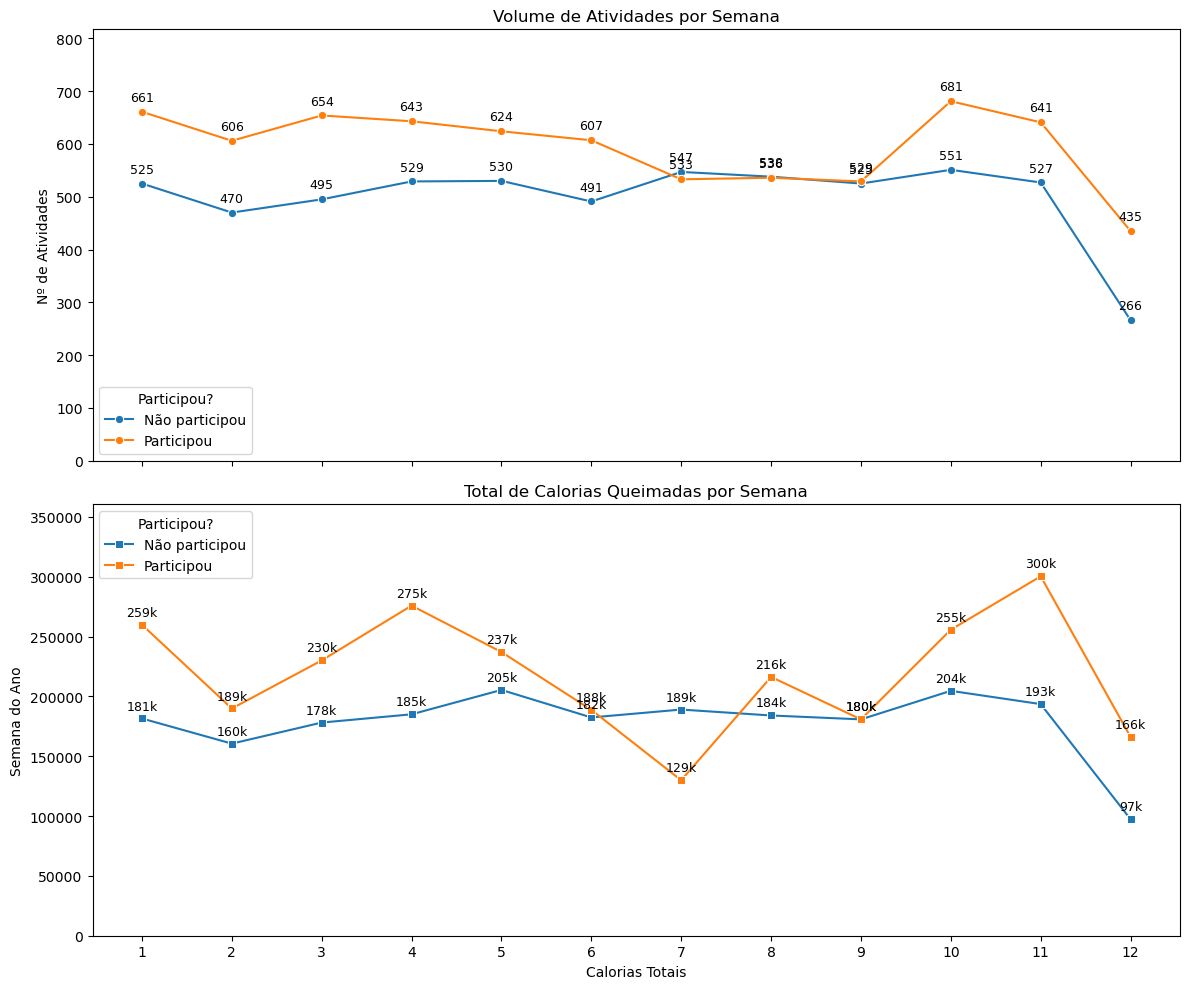

In [13]:
#Criando a coluna de label dos participantes
df_activities_full['participa_label'] = df_activities_full['participa'].map({True: 'Participou', False: 'Não participou'})

#Convertendo a coluna de data para datatime e extraindo o mês
df_activities_full['date'] = pd.to_datetime(df_activities_full['date'])
df_activities_full['month'] = df_activities_full['date'].dt.month

#Agregando semanas com mais densidade de participações e calorias
monthly_stats = df_activities_full.groupby(['month', 'participa_label']).agg(
    n_atividades=('activity_id', 'count'),
    total_calorias=('calories_burned', 'sum')
).reset_index()

#Tamanho dos gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#Densidade de atividades ao longo das semanas
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.lineplot(
    data=monthly_stats,
    x='month',
    y='n_atividades',
    hue='participa_label',
    ax=axes[0],
    marker='o',
    palette='tab10'
)

axes[0].set_title('Volume de Atividades por Semana')
axes[0].set_xlabel('Semana')
axes[0].set_ylabel('Nº de Atividades')
axes[0].legend(title='Participou?')

#Densidade de calorias ao longo das semanas
sns.lineplot(
    data=monthly_stats,
    x='month',
    y='total_calorias',
    hue='participa_label',
    ax=axes[1],
    marker='s',
    palette='tab10'
)

axes[1].set_title('Total de Calorias Queimadas por Semana')
axes[1].set_xlabel('Calorias Totais')
axes[1].set_ylabel('Semana do Ano')
axes[1].legend(title='Participou?')

#Ajustando eixo X do gráfico de 1 a 12 (Meses)
axes[1].set_xticks(range(1, 13))

#Adicionando números aos pontos do gráfico
for idx, row in monthly_stats.iterrows():
    #Nº de atividades
    axes[0].text(
        x=row['month'], 
        y=row['n_atividades'] + 15, # +15 para o texto ficar um pouco acima do ponto
        s=f"{int(row['n_atividades'])}", 
        color='black', 
        fontsize=9, 
        ha='center', 
        va='bottom'
    )
    #Calorias em formato "k"
    axes[1].text(
        x=row['month'], 
        y=row['total_calorias'] + 5000, 
        s=f"{int(row['total_calorias']/1000)}k", 
        color='black', 
        fontsize=9, 
        ha='center', 
        va='bottom'
    )

#Adicionando um limite extra no Y para os números não cortarem no topo
axes[0].set_ylim(0, monthly_stats['n_atividades'].max() * 1.2)
axes[1].set_ylim(0, monthly_stats['total_calorias'].max() * 1.2)

file_path = "../outputs/EDA_Bivariate/lineplot_semanas_densidade.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


Hipótese 2: *Desafios aumentam retenção:*
    Usuários que participam de desafios apresentam maior frequência de uso do aplicativo ao longo do tempo

        Métricas associadas:
            Média de visitas semanais à academia;
            Semanas com maior densidade de visitas à academia;
            Número de check-ins no app;
            Nível de sedentarismo dos participantes;

In [14]:
#Hipótese 2:

#--Média de visitas--

#1. Agrupando
avg_visits = weekly_visits.groupby('user_id')['weekly_gym_visits'].mean().reset_index()

#2. Renomeando para dar o merge
avg_visits.rename(columns={'weekly_gym_visits': 'avg_weekly_visits'}, inplace=True)

#Trava para evitar erro de merge deletando coluna caso ela exista
if 'avg_weekly_visits' in df_user.columns:
    df_user = df_user.drop(columns=['avg_weekly_visits'])

#3. Dando merge e preenchendo os nulos com 0
df_user = df_user.merge(avg_visits, on='user_id', how='left')
df_user['avg_weekly_visits'] = df_user['avg_weekly_visits'].fillna(0)

#--Densidade por semana--
#1. Dando merge para trazer label de quem participou
visits_com_label = weekly_visits.merge(df_user[['user_id', 'participa_label']], on='user_id', how='left')

#2. Agrupando pelos participantes e semanas
weeks_heatmap = visits_com_label.groupby(['participa_label', 'week'])['weekly_gym_visits'].mean().reset_index()

#3. Pivot para criar o heatmap
heatmap_pivot = weeks_heatmap.pivot(index='participa_label', columns='week', values='weekly_gym_visits')

#--Checkins dos usuários--
#1. Convertendo a coluna para Data no Pandas
user_app['checkin'] = pd.to_datetime(user_app['checkin'])

#2. Criando coluna apenas com datas mensais
user_app['checkin_month'] = user_app['checkin'].dt.to_period('M').astype(str)

#3. Merge com colunas necessárias -> Inner Join aqui para analisar apenas os check-ins de usuários que já estão na nossa base principal
checkins_com_label = user_app.merge(df_user[['user_id', 'participa_label']], on='user_id', how='inner')

#4.Agrupamento realizado em duas etapas para granularidade separada
#Etapa 1: Check-ins de cada um usuário em cada mês
user_monthly_checkins = checkins_com_label.groupby(['participa_label', 'checkin_month', 'user_id']).size().reset_index(name='total_checkins')

#Etapa 2: Média de checkins por mês de grupo inteiro
monthly_avg_checkins = user_monthly_checkins.groupby(['participa_label', 'checkin_month']).mean().reset_index()

#--Nível de sedentarismo dos participantes--
# 1. Utilizando a moda (valor que mais aparece) do sedentarismo para cada usuário, isso garante que teremos apenas 1 linha por user_id, mesmo que haja erro na base
sedent_mode = weekly_visits.groupby('user_id')['sedentarism_level'].agg(lambda x: x.mode()[0]).reset_index()

# 2. Trava de segurança para limpar colunas antigas antes do merge, para evitar erros
cols_to_drop = ['sedentarism_level', 'sedentarismo_texto']
df_user = df_user.drop(columns=[c for c in cols_to_drop if c in df_user.columns])

# 3. Dando merge da informação consolidada
df_user = df_user.merge(sedent_mode, on='user_id', how='left')

# 4. Mapeamento dos textos
df_user['sedentarismo_texto'] = df_user['sedentarism_level'].map({0: 'Ativo', 1: 'Sedentário'})

# 5. Cálculo da proporção percentual
sedentarism_perc = df_user.groupby('participa_label')['sedentarismo_texto'].value_counts(normalize=True).reset_index(name='proporcao')
sedentarism_perc['percentual'] = sedentarism_perc['proporcao'] * 100

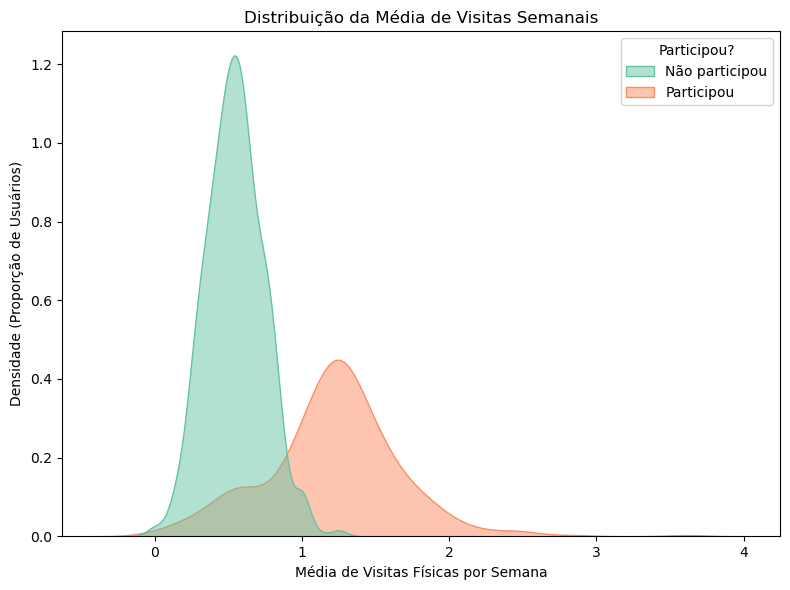

In [15]:
#Entendendo a frequência dos participantes

#Tamanho da figura
plt.figure(figsize=(8, 6))

#Criando o Boxplot
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.kdeplot(
    data=df_user.rename(columns={'participa_label': 'Participou?'}),
    x='avg_weekly_visits',
    hue='Participou?',
    fill=True,
    palette='Set2',
    alpha=0.5
)

plt.title('Distribuição da Média de Visitas Semanais')
plt.xlabel('Média de Visitas Físicas por Semana')
plt.ylabel('Densidade (Proporção de Usuários)')

file_path = "../outputs/EDA_Bivariate/lineplot_semanas_densidade.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

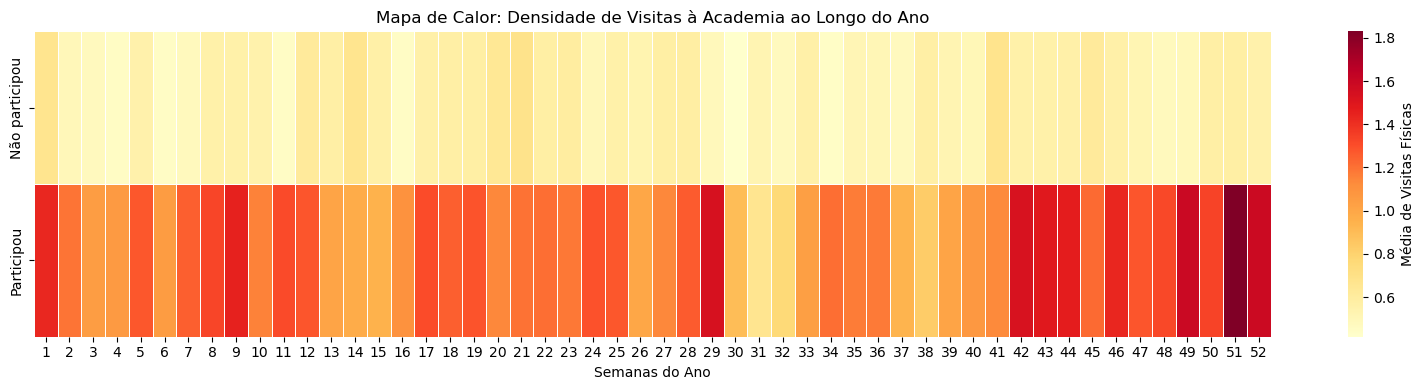

In [16]:
#Densidade por semana dos participantes
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Tamanho do gráfico
plt.figure(figsize=(16, 4))

#Heatmap
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',
    annot=False,   #Retirando os números dentro de cada quadrado e evitar poluição
    linewidths=.5, #Separando as semanas
    cbar_kws={'label': 'Média de Visitas Físicas'}
)

plt.title('Mapa de Calor: Densidade de Visitas à Academia ao Longo do Ano')
plt.xlabel('Semanas do Ano')
plt.ylabel('')

file_path = '../outputs/EDA_Bivariate/heatmap_visitas_semanas.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

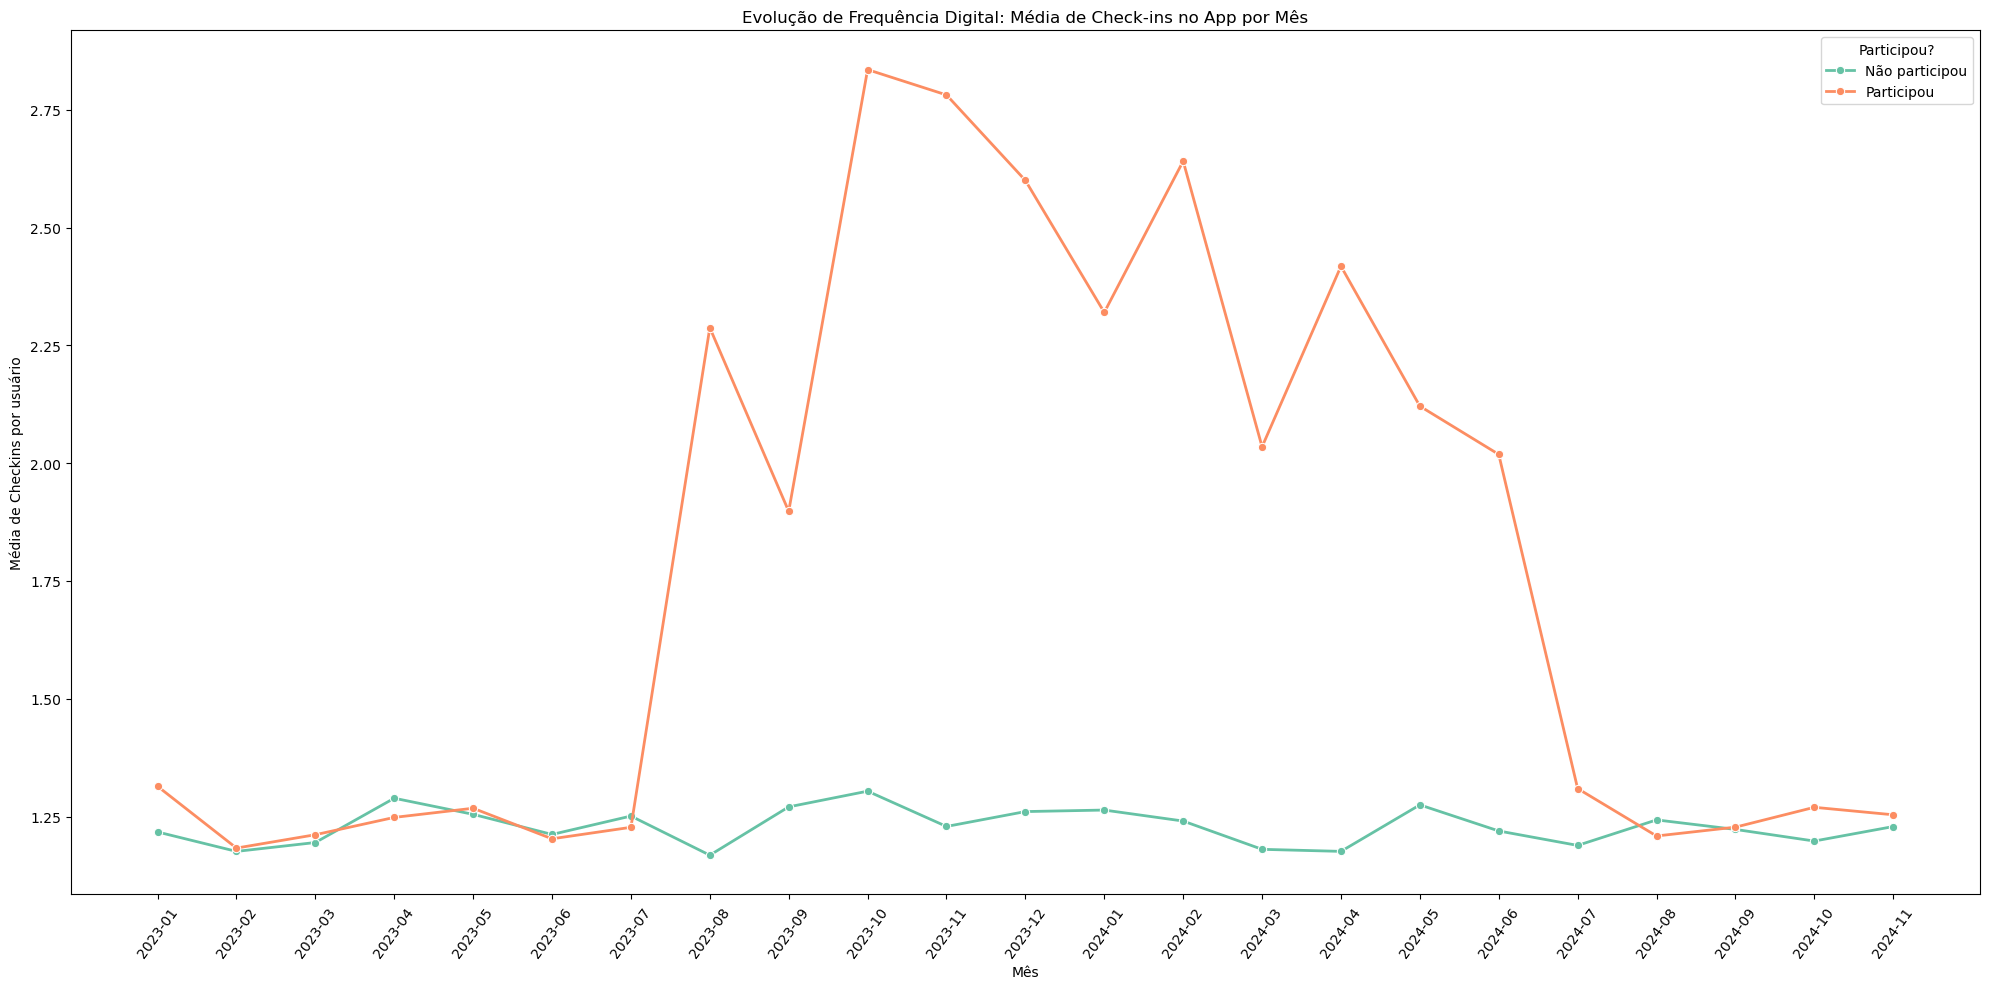

In [17]:
#Distribuição dos checkins ao longo do tempo
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Tamanho do gráfico
plt.figure(figsize=(20, 10))

#Plotando o gráfico
sns.lineplot(
    data=monthly_avg_checkins.rename(columns={'participa_label': 'Participou?'}),
    x='checkin_month',
    y='total_checkins',
    hue='Participou?',
    palette='Set2',
    marker='o',
    linewidth=2
)

plt.title('Evolução de Frequência Digital: Média de Check-ins no App por Mês')
plt.xlabel('Mês')
plt.ylabel('Média de Checkins por usuário')
plt.xticks(rotation=54)

file_path = '../outputs/EDA_Bivariate/lineplot_checkins_mensais.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

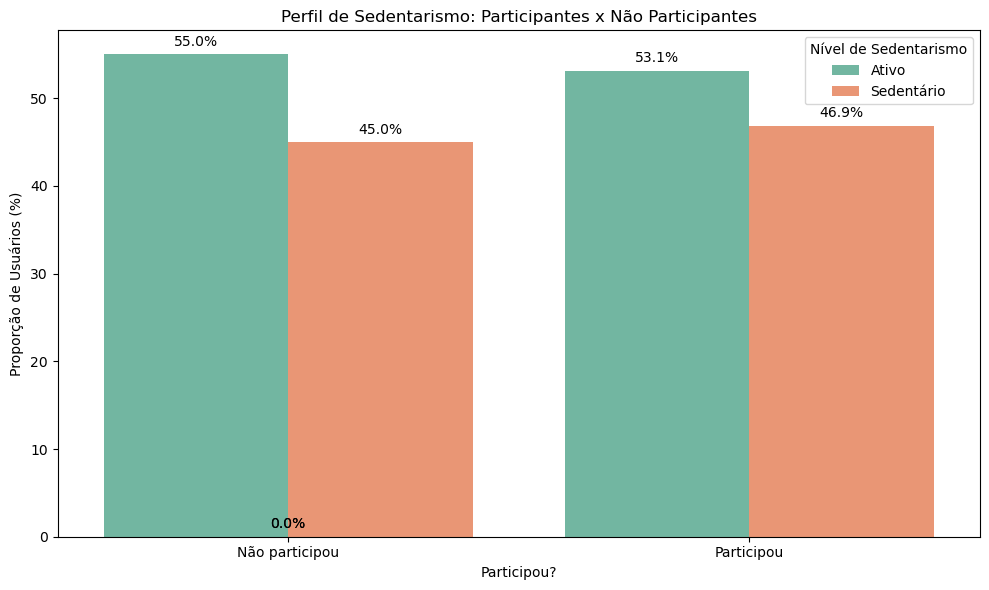

In [18]:
#Visualização dos níveis de sedentarismo
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Tamanho do gráfico
plt.figure(figsize=(10, 6))

#Plotando o gráfico
ax = sns.barplot(
    data=sedentarism_perc.rename(columns={'participa_label': 'Participou?'}),
    x='Participou?',
    y='percentual',
    hue='sedentarismo_texto',
    palette='Set2'
)

#Adicionando os valores nas barras para conferência
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.title('Perfil de Sedentarismo: Participantes x Não Participantes')
plt.xlabel('Participou?')
plt.ylabel('Proporção de Usuários (%)')
plt.legend(title='Nível de Sedentarismo', loc='upper right')

file_path = '../outputs/EDA_Bivariate/barplot_sedentarismo.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

Hipótese 3: *Desafios estimulam mais atividade física:* O acúmulo de desafios eleva significativamente a intensidade e a qualidade do rendimento físico do usuário, transformando a vida das pessoas, tornando elas mais ativas e garantindo a retenção dos usuários no aplicativo.

        Métricas associadas:
            Média de steps e calorias de acordo com o volume de desafios que o usuário participa;
            Churn dos usuários;
            Usuários que batem 'metas de alto rendimento' de acordo com os desafios.

In [39]:
#Hipótese 3:

#1. Criando o dataframe base
df_h3 = df_user[['user_id']].copy()

#2. Calculando as médias de saúde (Steps e Calorias)
user_health_metrics = activities.groupby('user_id')[['steps', 'calories_burned']].mean().reset_index()
user_health_metrics.rename(columns={'steps': 'avg_steps', 'calories_burned': 'avg_calories'}, inplace=True)

#3. Contando quantos desafios cada usuário participou
user_challenges = desafio_usuario.groupby('user_id')['desafio_id'].nunique().reset_index(name='qtd_desafios')

#4. Dando Merge nas colunas devidamente
df_h3 = df_h3.merge(user_challenges, on='user_id', how='left')
df_h3 = df_h3.merge(user_health_metrics, on='user_id', how='left')
df_retencao = pd.merge(desafio_usuario, challenges, left_on = 'desafio_id', right_on = 'id_desafio', how = 'inner')

#5. Preenchendo os nulos
df_h3['qtd_desafios'] = df_h3['qtd_desafios'].fillna(0).astype(int)
df_h3[['avg_steps', 'avg_calories']] = df_h3[['avg_steps', 'avg_calories']].fillna(0)

#6. Criando os grupos para melhor visualização
def categorizar_desafios(qtd):
    if qtd == 0: return '0 Desafios'
    elif qtd == 1: return '1 Desafio'
    elif qtd == 2: return '2 Desafios'
    else: return '3+ Desafios'

df_h3['grupo_desafios'] = df_h3['qtd_desafios'].apply(categorizar_desafios)

ordem = ['0 Desafios', '1 Desafio', '2 Desafios', '3+ Desafios']
df_h3['grupo_desafios'] = pd.Categorical(df_h3['grupo_desafios'], categories=ordem, ordered=True)

#7. Aplicando a regra de alto rendimento dos participantes
df_h3['alto_rendimento'] = (df_h3['avg_steps'] >= 10000) | (df_h3['avg_calories'] >= 400)

#8. Calculando as métricas finais
##a. Taxa de sucesso
taxa_sucesso = df_h3.groupby('grupo_desafios')['alto_rendimento'].mean().reset_index()
taxa_sucesso['taxa_percentual'] = taxa_sucesso['alto_rendimento'] * 100

##b. Cálculo de Retenção -> Aqui presumi as taxas de conclusão por esporte presentes no dataset 'desafio_usuario', onde quem tem uma linha aqui, indica que ao menos começou o desafio.
taxa_retencao = df_retencao.groupby('activity_type').agg(
    taxa_conclusao = ('completou', 'mean') #Média de 0 ou 1
).reset_index()

#Calculando a taxa de desistência (100% = Taxa de Conslusão)
taxa_retencao['taxa_sem_conclusao'] = 1 - taxa_retencao['taxa_conclusao']

##d. Ordenando os dados
taxa_retencao = taxa_retencao.sort_values(by = 'taxa_conclusao', ascending = False)

C:\Users\Nicolas Freitas\AppData\Local\Temp\ipykernel_18412\2134680936.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_sucesso = df_h3.groupby('grupo_desafios')['alto_rendimento'].mean().reset_index()


In [40]:
#Verificando a quantidade total de números absolutos
print('--- Quantidade Geral de Retenção ---')
print(df_retencao['completou'].map({1: 'Completou', 0: 'Desistiu'}).value_counts())

--- Quantidade Geral de Retenção ---
completou
Completou    390
Desistiu     106
Name: count, dtype: int64


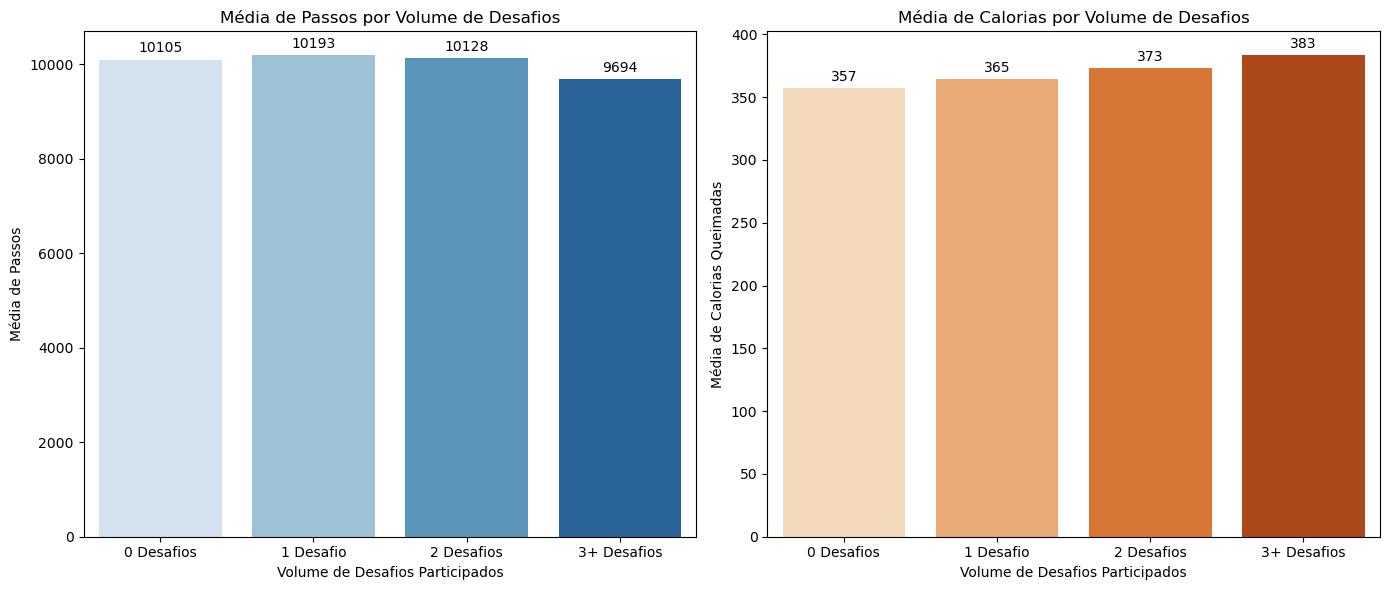

In [20]:
#Visualização dos Steps e Calorias por volume de desafios
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Criando o gráfico com 1 linha e 2 colunas -> Steps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Gráfico de Passos
sns.barplot(
    data=df_h3,
    x = 'grupo_desafios',
    y = 'avg_steps',
    hue = 'grupo_desafios',
    ax = axes[0],
    legend = False,
    errorbar = None,
    palette = 'Blues',
    dodge = False
)

axes[0].set_title('Média de Passos por Volume de Desafios')
axes[0].set_xlabel('Volume de Desafios Participados')
axes[0].set_ylabel('Média de Passos')

#Adicionando valores nas barras do gráfico
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha = 'center', 
        va = 'center',
        xytext = (0, 8),
        textcoords = 'offset points')
    
#Criando o gráfico para calorias queimadas
sns.barplot(
    data = df_h3,
    x = 'grupo_desafios',
    y = 'avg_calories',
    hue = 'grupo_desafios',
    ax = axes[1],
    legend = False,
    errorbar = None,
    palette = 'Oranges',
    dodge = False
)

axes[1].set_title('Média de Calorias por Volume de Desafios')
axes[1].set_xlabel('Volume de Desafios Participados')
axes[1].set_ylabel('Média de Calorias Queimadas')

# Adicionando os valores nas barras do de calorias
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha = 'center', 
        va = 'center', 
        xytext = (0, 8), 
        textcoords = 'offset points')

#Ajustando o layout e salvando
file_path = '../outputs/EDA_Bivariate/barplots_h3_dose_resposta.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


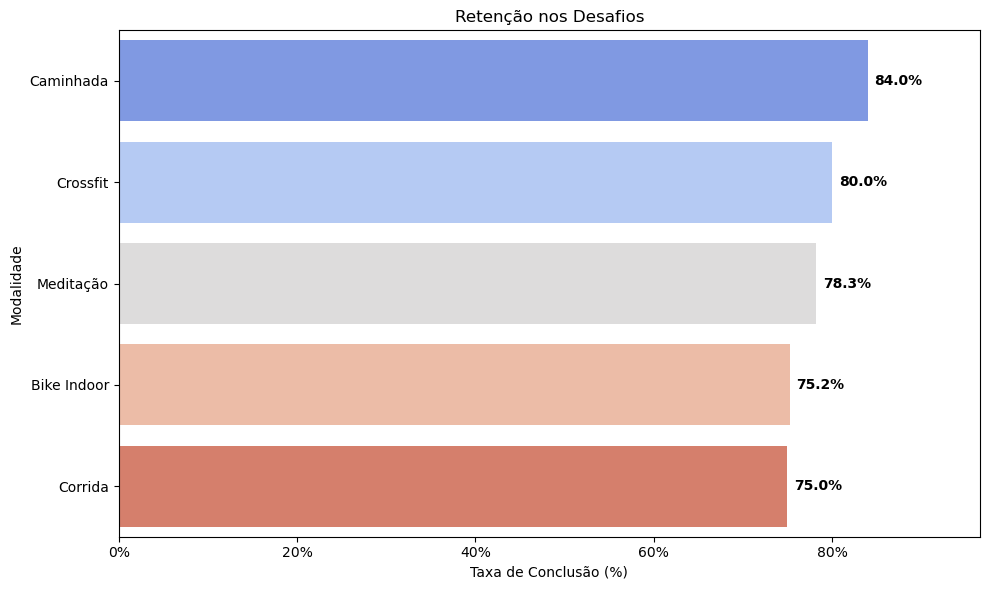

In [38]:
#Gráfico de Retenção (Churn)
os.makedirs('../outputs/EDA_Bivariate', exist_ok = True)

#Tamanho do gráfico
fig, ax = plt.subplots(figsize = (10, 6))

#Plotando o gráfico
sns.barplot(
    data = taxa_retencao,
    y = 'activity_type',
    x = 'taxa_conclusao',
    ax = ax,
    hue = 'activity_type',
    palette = 'coolwarm',
    legend = False
)

ax.set_title('Retenção nos Desafios')
ax.set_xlabel('Taxa de Conclusão (%)')
ax.set_ylabel('Modalidade')

#Formatando o eixo X para porcentagem
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Aumentando o limite do eixo X em 15% para dar espaço ao texto
ax.set_xlim(0, taxa_retencao['taxa_conclusao'].max() * 1.15)

#Adicionando os rótulos de dados (porcentagem) na ponta das barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width*100:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), textcoords='offset points',
                    fontweight='bold')
        
#Ajustando layout e salvando
file_path = '../outputs/EDA_Bivariate/bar_retencao_desafios.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches = 'tight')
plt.show()
plt.close()

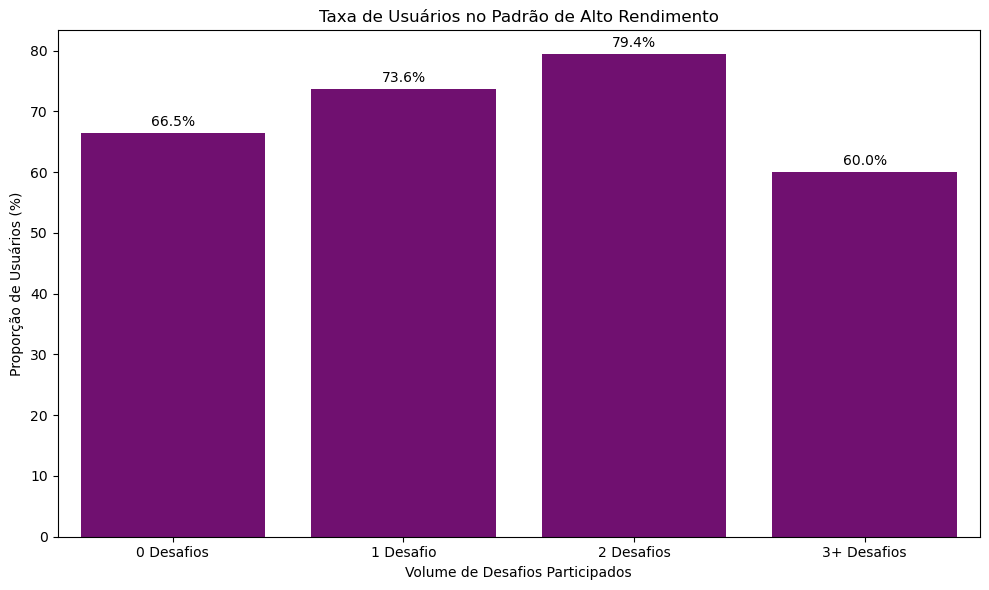

In [22]:
#Gráfico de taxa de alto rendimento
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Tamanho do gráfico
plt.figure(figsize=(10, 6))

#Plotando o gráfico
ax = sns.barplot(
    data = taxa_sucesso,
    x = 'grupo_desafios',
    y = 'taxa_percentual',
    color = 'Purple',
    legend = False
)

plt.title('Taxa de Usuários no Padrão de Alto Rendimento')
plt.xlabel('Volume de Desafios Participados')
plt.ylabel('Proporção de Usuários (%)')

# Adicionando a porcentagem em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 8),
        textcoords='offset points')
    
#Ajustando layout e salvando
file_path = '../outputs/EDA_Bivariate/barplot_h3_alto_rendimento.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


Hipótese 4: *Usuários que participam de mais desafios apresentam maior nível de engajamento:*

    A probabilidade de participação em desafios varia de acordo com características do usuário.
        Métricas associadas:
            Taxa de participação por grupo de idade;
            Taxa de participação por gênero;
            Taxa de participação pela distância da acadêmia.

In [23]:
#Hipótese 4:
#1. Criando a coluna participa em formato numérico
df_user['participa_num'] = df_user['participa'].map({False: 0, True: 1})

#2. Criando os grupos para melhor visualização
def categorizar_distancia(qtd):
    if qtd <= 2: return 'Até 2km'
    elif qtd <= 5: return '2 a 5km'
    elif qtd <= 10: return '5 a 10km'
    else: return '10km+'

df_user['grupo_distancia'] = df_user['distance_to_gym'].apply(categorizar_distancia)

#3. Ordenando os grupos
##Distância
ordem_dist = ['Até 2km', '2 a 5km', '5 a 10km', '10km+']
df_user['grupo_distancia'] = pd.Categorical(df_user['grupo_distancia'], categories=ordem_dist, ordered=True)

##Idade
ordem_idade = ['18-25','26-35', '36-50', '51+']
df_user['age_group'] = pd.Categorical(df_user['age_group'], categories=ordem_idade, ordered=True)

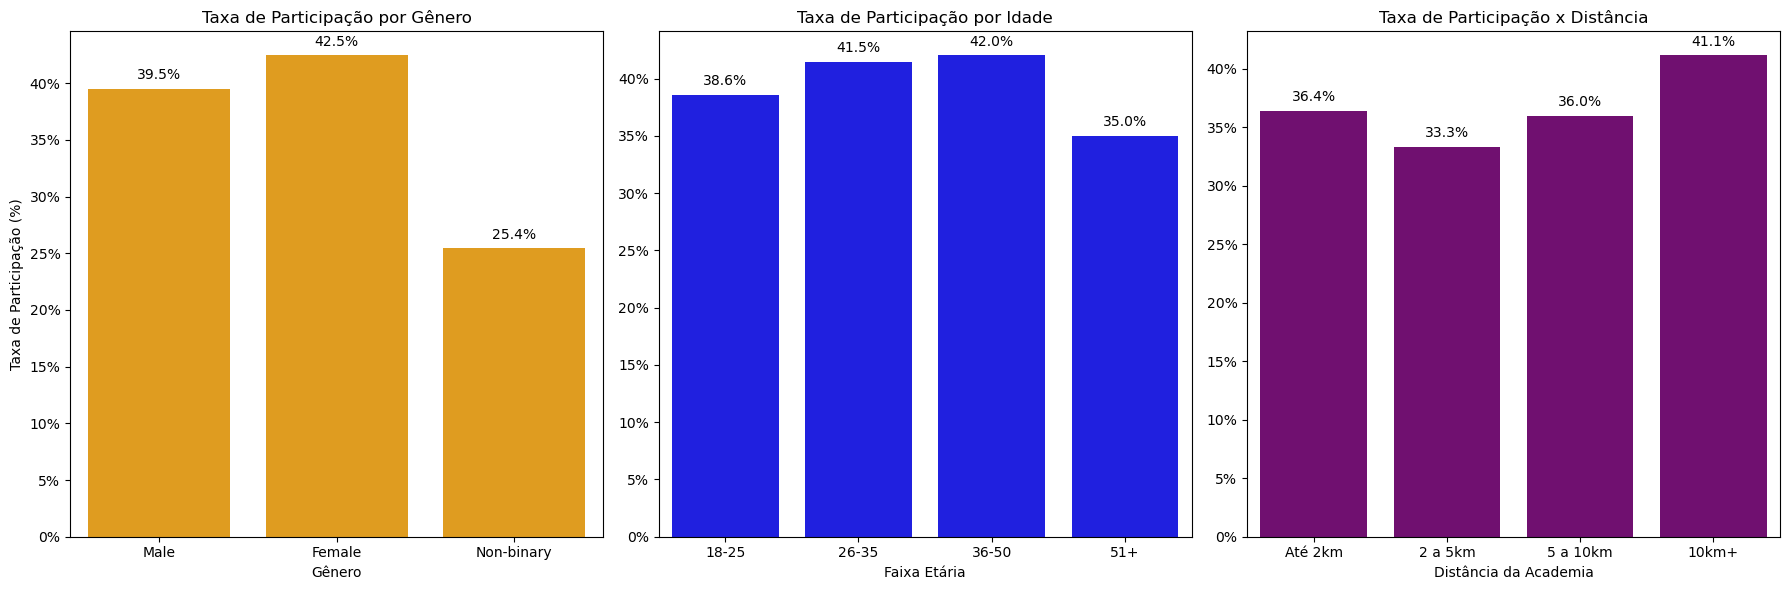

In [24]:
#Gráficos para as variáveis de Gênero, Idade e Distância
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

#Criando subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Plotando o gráfico de Gênero
sns.barplot(data = df_user,
    x = 'gender',
    y = 'participa_num',
    ax=axes[0],
    color = 'Orange',
    legend=False,
    errorbar=None
)

axes[0].set_title('Taxa de Participação por Gênero')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Taxa de Participação (%)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

#Plotando o gráfico de Idade
sns.barplot(
    data = df_user,
    x = 'age_group',
    y = 'participa_num',
    ax = axes[1],
    color = 'blue',
    legend = False,
    errorbar = None
)

axes[1].set_title('Taxa de Participação por Idade')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

#Plotando gráfico por Distância da Academia
sns.barplot(
    data = df_user,
    x = 'grupo_distancia',
    y = 'participa_num',
    ax = axes[2],
    color = 'purple',
    legend = False,
    errorbar = None
)

axes[2].set_title('Taxa de Participação x Distância')
axes[2].set_xlabel('Distância da Academia')
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Adicionando os rótulos de dados (porcentagem) em cima das barras
for ax in axes:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points')
            
#Ajustando layout e salvando
file_path = '../outputs/EDA_Bivariate/barplots_h4_demografico.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches = 'tight')
plt.show()
plt.close()


Hipótese 5: *Desafios geram mais frequência de uso:*

    O tipo de atividade do desafio influencia a taxa de participação dos usuários.
        Métricas associadas:
            Número de participantes por tipo de atividade;
            Média de participação por desafio.

In [25]:
#Hipótese 5:

#1. Dando merge nos datasets
df_h5 = pd.merge(desafio_usuario, challenges, left_on = 'desafio_id', right_on = 'id_desafio', how = 'inner')

#2. Calcular o volume total
total_por_atividade = df_h5.groupby('activity_type').agg(
    total_participacoes = ('user_id', 'count')
).reset_index()

#3. Calcular a média por desafio
##3.1 Contar quantas pessoas participaram de cada desafio individualmente
pessoas_por_desafio = df_h5.groupby(['activity_type', 'desafio_id']).agg(
    participantes = ('user_id', 'count')
).reset_index()

##3.2 Média de pessoas por atividade
media_por_desafio = pessoas_por_desafio.groupby('activity_type').agg(
    media_participates = ('participantes', 'mean')
).reset_index()

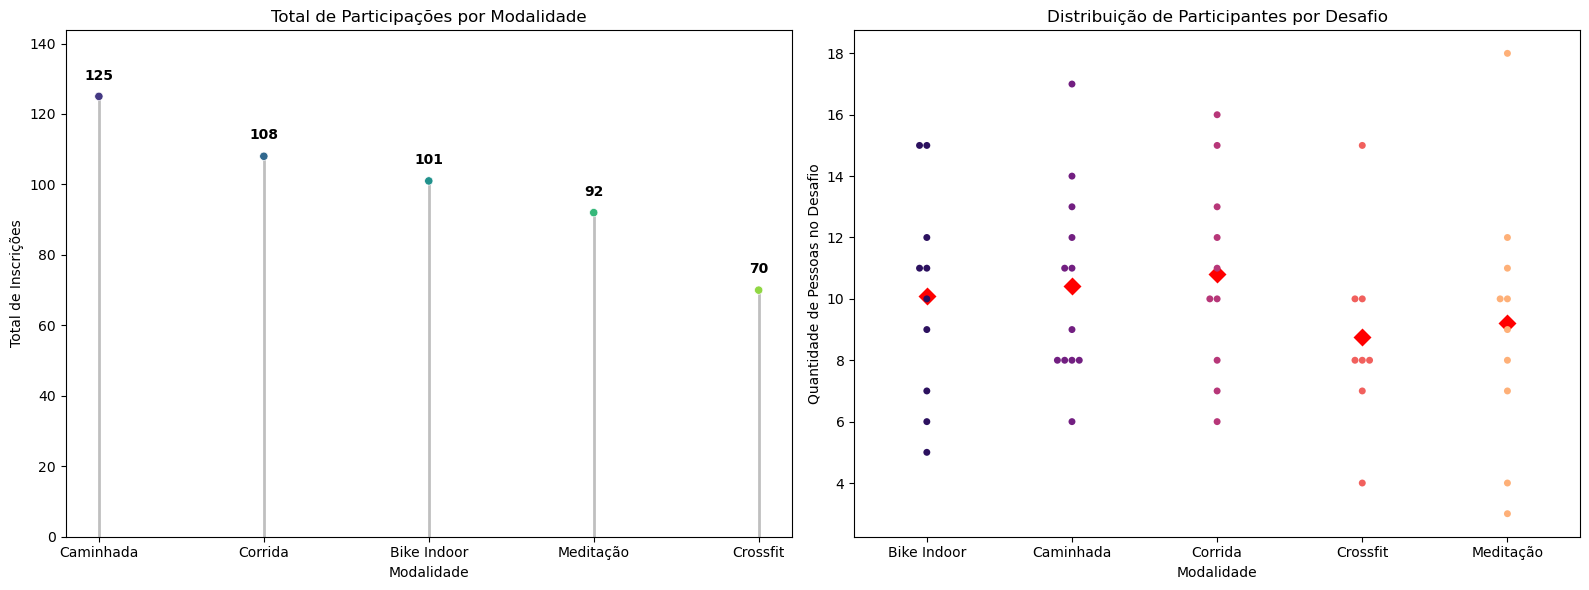

In [26]:
#Gráfico para visualização das atividades
os.makedirs('../outputs/EDA_Bivariate', exist_ok = True)

#Ajustando tamanho dos gráficos
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

#Plotando o gráfico de Volume Total
##1. Ordenando os dados
total_por_atividade = total_por_atividade.sort_values(by = 'total_participacoes', ascending = False)

##2. Desenhando as 'hastes' do gráfico
axes[0].vlines(
    x = total_por_atividade['activity_type'],
    ymin = 0,
    ymax = total_por_atividade['total_participacoes'],
    color = 'gray',
    alpha = 0.5,
    linewidth = 2 
)

##3. Desenhando o scatterplot
sns.scatterplot(
    data = total_por_atividade,
    x = 'activity_type',
    y = 'total_participacoes',
    ax = axes[0],
    hue = 'activity_type',
    palette = 'viridis',
    legend = False,
    zorder = 3
)

axes[0].set_title('Total de Participações por Modalidade')
axes[0].set_xlabel('Modalidade')
axes[0].set_ylabel('Total de Inscrições')
axes[0].set_ylim(0, total_por_atividade['total_participacoes'].max() * 1.15)

##4. Rótulos do gráfico
for index, row in total_por_atividade.iterrows():
    axes[0].annotate(f"{int(row['total_participacoes'])}", 
                     (row['activity_type'], row['total_participacoes']), 
                     ha='center', va='center', xytext=(0, 15), textcoords='offset points', fontweight='bold')
    
#Gráfico para a dispersão
sns.swarmplot(
    data = pessoas_por_desafio,
    x = 'activity_type',
    y = 'participantes',
    ax = axes[1],
    hue = 'activity_type',
    palette = 'magma',
    legend = False
)

##1. Mostrando a média
sns.pointplot(
    data = pessoas_por_desafio, 
    x = 'activity_type', 
    y = 'participantes', 
    ax = axes[1], 
    color = 'red', 
    markers = 'D', 
    linestyles = '', 
    errorbar = None
)

axes[1].set_title('Distribuição de Participantes por Desafio')
axes[1].set_ylabel('Quantidade de Pessoas no Desafio')
axes[1].set_xlabel('Modalidade')

# Ajustando layout e salvando
plt.tight_layout()

file_path = '../outputs/EDA_Bivariate/scatter_h5_modalidades.png'

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

Hipótese 6: Usuários com maior nível de atividade:

    Usuários apresentam maior volume de atividades durante o período de participação em desafios.
        Métricas associadas:
            Número de atividades durante período do desafio.

In [27]:
#Hipótese 6:

##1. Organizar o calendário para datetime
activities['date'] = pd.to_datetime(activities['date'])
challenges['data_inicio'] = pd.to_datetime(challenges['data_inicio'])
challenges['data_fim'] = pd.to_datetime(challenges['data_fim'])

##2. Dando merge para o mapa de desafios do usuário 
df_mapa_desafios = pd.merge(desafio_usuario, challenges, left_on = 'desafio_id', right_on = 'id_desafio', how = 'inner')

##3. Nova coluna de em_desafio para os usuários
#Dando merge nas atividades
df_cruzamento = pd.merge(activities, df_mapa_desafios[['user_id', 'data_inicio', 'data_fim']],
    on = 'user_id',
    how = 'left'
)

#Criando regra para exercício dentro da janela de desafios
df_cruzamento['is_durante'] = (df_cruzamento['date'] >= df_cruzamento['data_inicio']) & (df_cruzamento['date'] <= df_cruzamento['data_fim'])

#Agrupando por ID da atividade
df_atividades_classificadas = df_cruzamento.groupby('activity_id').agg(
    user_id = ('user_id', 'first'),
    em_desafio = ('is_durante', 'any')
).reset_index()

#Transformando os booleanos em texto
df_atividades_classificadas['status_desafio'] = df_atividades_classificadas['em_desafio'].map({
    True: 'Durante Desafio',
    False: 'Fora de Desafio'
})

print(df_atividades_classificadas['status_desafio'].value_counts())

status_desafio
Fora de Desafio    13053
Durante Desafio       91
Name: count, dtype: int64


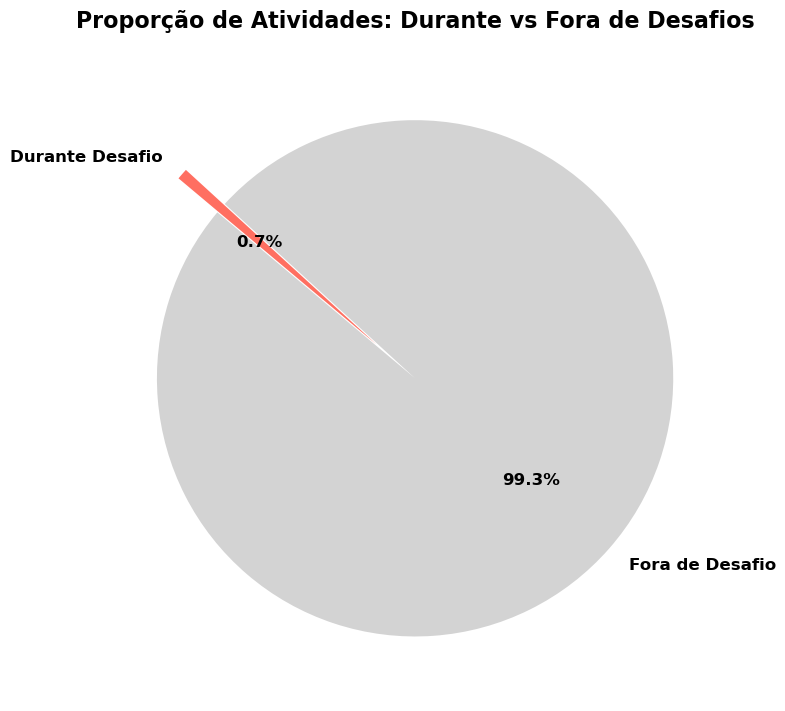

In [28]:
#Gráfico de pizza para visualização dos resultados
os.makedirs('../outputs/EDA_Bivariate', exist_ok = True)

dados_grafico_rosca = df_atividades_classificadas['status_desafio'].value_counts()
labels = dados_grafico_rosca.index
valores = dados_grafico_rosca.values
cores = ['#d3d3d3', '#ff6f61']

#Tamanho do gráfico
fig, ax = plt.subplots(figsize=(8, 8))

explodir = (0, 0.2)

#Plotando o gráfico de pizza
wedges, texts, autotexts = ax.pie(
    valores, 
    labels = labels, 
    autopct = '%1.1f%%', 
    startangle = 140, 
    colors = cores,
    explode = explodir,
    textprops = dict(color="black", fontsize=12, weight="bold")
)

ax.set_title('Proporção de Atividades: Durante vs Fora de Desafios', fontsize=16, fontweight='bold', pad=20)

#Ajustando o layout e salvando
plt.tight_layout()

file_path = '../outputs/EDA_Bivariate/pie_h6_atividades_desafio.png'

plt.savefig(file_path, bbox_inches = 'tight')
plt.show()
plt.close()

Hipótese 7: Usuários pagantes participam mais dos desafios

    Usuários que são pagantes participam mais e são mais engajados nos desafios.
        Métricas associadas:
            Usuários pagantes x Taxa de Conclusão.

In [46]:
#Hipótese 7:

#1. Dando merge nas tabelas dos planos
df_planos_retencao = pd.merge(
    df_retencao,
    user_plan[['user_id', 'plano']],
    on = 'user_id',
    how = 'inner'
)

#2. Calculando a taxa de conclusão e o volume por tipo de plano
taxa_plano = df_planos_retencao.groupby('plano').agg(
    total_inscritos = ('completou', 'count'),
    taxa_conclusao = ('completou', 'mean')
).reset_index()

In [43]:
#Vendo os números absolutos no notebook para registro
print('--- Números Absolutos por Plano ---')
print(taxa_plano)

--- Números Absolutos por Plano ---
     plano  total_inscritos  taxa_conclusão
0   Grátis              496         0.78629
1  Pagante              334         0.92515


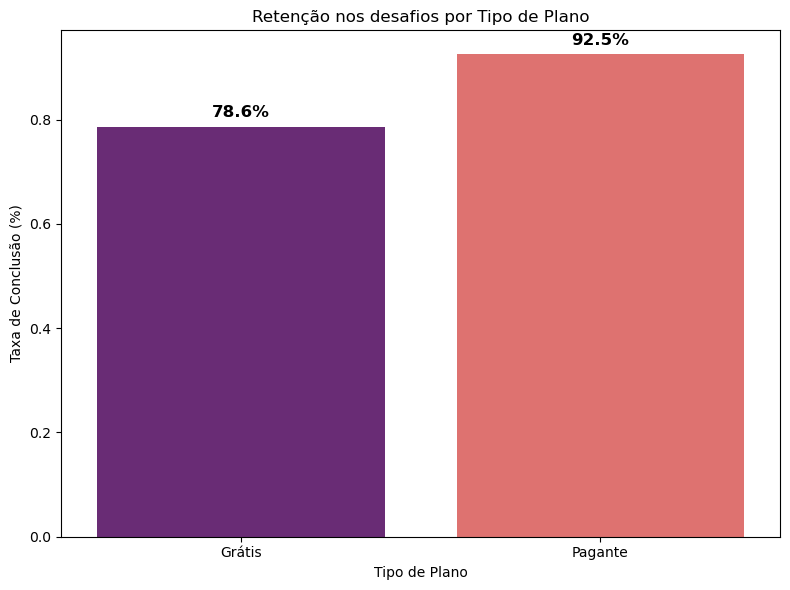

In [47]:
#Gráfico para taxa de Inscritos x Conclusão
os.makedirs('../outputs/EDA_Bivariate', exist_ok = True)

#Tamanho do gráfico
fig, ax = plt.subplots(figsize = (8, 6))

#Plotando o gráfico
sns.barplot(
    data = taxa_plano,
    x = 'plano',
    y = 'taxa_conclusao',
    hue = 'plano',
    palette = 'magma',
    ax = ax,
    legend = False
)

ax.set_title('Retenção nos desafios por Tipo de Plano')
ax.set_xlabel('Tipo de Plano')
ax.set_ylabel('Taxa de Conclusão (%)')

# Adicionando os rótulos de dados em cima das barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontweight='bold', fontsize=12)
        
#Ajustando o layout e salvando
file_path = '../outputs/EDA_Bivariate/barplot_retencao_por_plano.png'

plt.tight_layout()
plt.savefig(file_path, bbox_inches = 'tight')
plt.show()
plt.close()